In [1]:
!pip install pandas scikit-learn matplotlib

Decision Tree Model:
DecisionTreeClassifier()


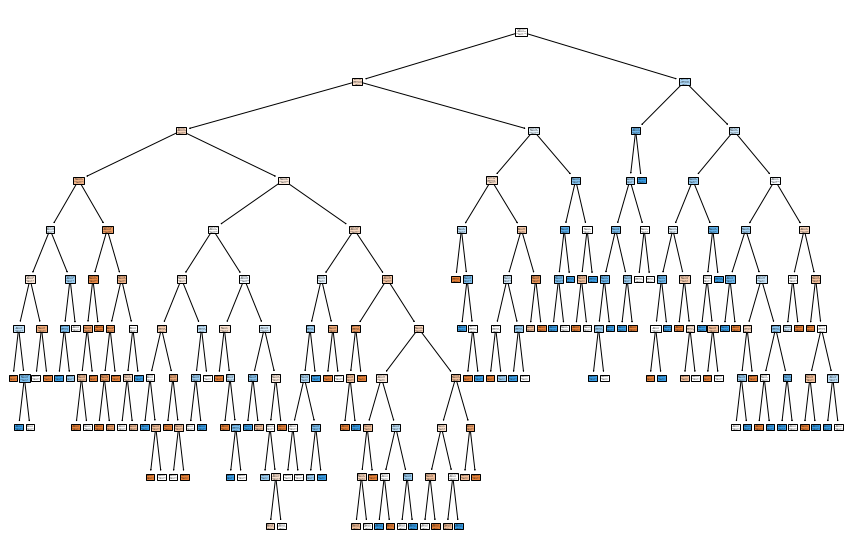


Evaluation Metrics:
Accuracy: 0.4166666666666667
Correctly classified : 41.66666666666667 %
Wrongly Classified : 58.33333333333333 %
Mean Absolute Error: 0.5833333333333334
Root Mean Squared Error: 0.7637626158259734


In [2]:
import pandas as pd
import random
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import random
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

data = []
for _ in range(300):
    age = random.choice(['young', 'middle', 'old'])
    job = random.choice(['admin', 'tech', 'services', 'management'])
    income = random.choice(['low', 'medium', 'high'])
    credit = random.choice(['good', 'bad'])
    education = random.choice(['highschool', 'bachelor', 'master'])
    label = random.choice(['0', '1'])
    data.append([age, job, income, credit, education, label])

dataset = pd.DataFrame(data, columns=['age', 'job', 'income', 'credit', 'education', 'class'])

label_encoder = LabelEncoder()

for column in dataset.columns:
    if dataset[column].dtype == 'object':
        dataset[column] = label_encoder.fit_transform(dataset[column])

X = dataset.drop('class', axis=1)
y = dataset['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Decision Tree Model:")
print(model)

plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=list(X.columns), class_names=['0', '1'], filled=True)
plt.show()

perc_crct = accuracy * 100
perc_wrong = 100 - perc_crct

print("\nEvaluation Metrics:")
print("Accuracy:", accuracy)
print("Correctly classified :", perc_crct, "%")
print("Wrongly Classified :", perc_wrong, "%")
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", mse ** 0.5)